# Conformal Prediction Intervals for Production Forecasts

**Goal:** attach *guaranteed-coverage* intervals to a production forecaster, then make
them adaptive with conformalized quantile regression.

**Technique highlights**
* **Split conformal**: calibration-set residual quantile → finite-sample guarantee
* **CQR**: quantile-regression base + conformal correction → adaptive widths
* Empirical audits: marginal coverage, conditional coverage by completion size

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic well dataset with heteroscedastic outcomes

In [2]:
N = 3_000
lateral_ft = rng.uniform(4_000, 12_000, N)
proppant_lbft = rng.uniform(800, 2_800, N)
stages = (lateral_ft / rng.uniform(180, 260, N)).round()
phi_h = rng.normal(120, 25, N).clip(50, 200)        # porosity-thickness
pressure_dep = rng.uniform(0, 1, N)                  # depletion from parents

mean_cum = (28 * (lateral_ft / 7_500) ** 0.85 * (proppant_lbft / 1_800) ** 0.4
            * (phi_h / 120) * (1 - 0.35 * pressure_dep))
noise_sd = 0.10 + 0.18 * (proppant_lbft / 2_800)     # bigger jobs, wider outcomes
cum12 = mean_cum * rng.lognormal(0, noise_sd)

df = pd.DataFrame({"lateral_ft": lateral_ft.round(0),
                   "proppant_lbft": proppant_lbft.round(0), "stages": stages,
                   "phi_h": phi_h.round(1), "pressure_dep": pressure_dep.round(2),
                   "cum12_mboe": cum12.round(2)})
df.to_csv("well_cum12_data.csv", index=False)

## 2. Split conformal around a point forecaster

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

FEATURES = df.columns[:-1].tolist()
X_temp, X_test, y_temp, y_test = train_test_split(df[FEATURES], df.cum12_mboe,
                                                  test_size=0.25, random_state=42)
X_train, X_cal, y_train, y_cal = train_test_split(X_temp, y_temp, test_size=0.33,
                                                  random_state=42)
ALPHA = 0.10

gb = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                               random_state=42).fit(X_train, y_train)
cal_resid = np.abs(y_cal - gb.predict(X_cal))
n_cal = len(cal_resid)
q_hat = np.quantile(cal_resid, np.ceil((1 - ALPHA) * (n_cal + 1)) / n_cal)

pred = gb.predict(X_test)
lo_sc, hi_sc = pred - q_hat, pred + q_hat
cover_sc = ((y_test >= lo_sc) & (y_test <= hi_sc)).mean()
print(f"Split conformal 90% interval: empirical coverage {cover_sc:.1%}, "
      f"constant width {2 * q_hat:.1f} Mboe")

Split conformal 90% interval: empirical coverage 91.6%, constant width 21.3 Mboe


## 3. CQR — adaptive widths

In [4]:
q_lo = GradientBoostingRegressor(loss="quantile", alpha=0.05, n_estimators=400,
                                 max_depth=3, learning_rate=0.05, random_state=42
                                 ).fit(X_train, y_train)
q_hi = GradientBoostingRegressor(loss="quantile", alpha=0.95, n_estimators=400,
                                 max_depth=3, learning_rate=0.05, random_state=42
                                 ).fit(X_train, y_train)
scores = np.maximum(q_lo.predict(X_cal) - y_cal, y_cal - q_hi.predict(X_cal))
q_corr = np.quantile(scores, np.ceil((1 - ALPHA) * (n_cal + 1)) / n_cal)

lo_cqr = q_lo.predict(X_test) - q_corr
hi_cqr = q_hi.predict(X_test) + q_corr
cover_cqr = ((y_test >= lo_cqr) & (y_test <= hi_cqr)).mean()
print(f"CQR 90% interval: empirical coverage {cover_cqr:.1%}, "
      f"mean width {np.mean(hi_cqr - lo_cqr):.1f} Mboe "
      f"(width range {np.min(hi_cqr - lo_cqr):.0f}–{np.max(hi_cqr - lo_cqr):.0f})")

CQR 90% interval: empirical coverage 92.1%, mean width 19.6 Mboe (width range 4–55)


## 4. Audits

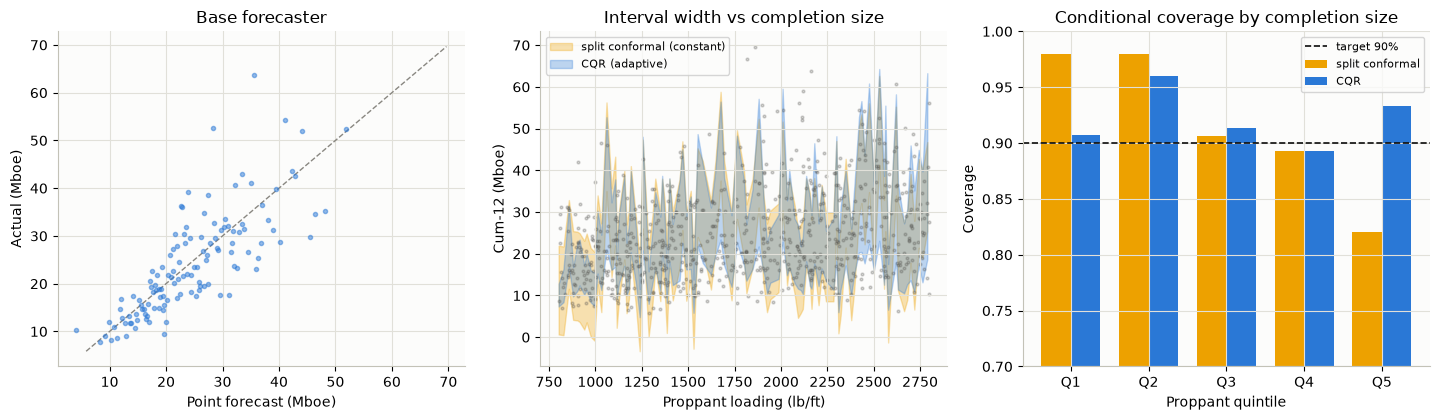

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
order = np.argsort(pred)[::6]
axes[0].errorbar(pred[order], y_test.values[order],
                 xerr=None, fmt="o", ms=3, color=PALETTE[0], alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             ls="--", lw=1, color="#898781")
axes[0].set(xlabel="Point forecast (Mboe)", ylabel="Actual (Mboe)",
            title="Base forecaster")

idx = np.argsort(X_test.proppant_lbft.values)[::8]
xw = X_test.proppant_lbft.values[idx]
axes[1].fill_between(xw, lo_sc[idx], hi_sc[idx], color=PALETTE[2], alpha=0.3,
                     label="split conformal (constant)")
axes[1].fill_between(xw, lo_cqr[idx], hi_cqr[idx], color=PALETTE[0], alpha=0.3,
                     label="CQR (adaptive)")
axes[1].scatter(X_test.proppant_lbft, y_test, s=4, alpha=0.25, color="#52514e")
axes[1].set(xlabel="Proppant loading (lb/ft)", ylabel="Cum-12 (Mboe)",
            title="Interval width vs completion size")
axes[1].legend(fontsize=8)

bins = pd.qcut(X_test.proppant_lbft, 5)
cond = pd.DataFrame({"bin": bins,
                     "sc": (y_test >= lo_sc) & (y_test <= hi_sc),
                     "cqr": (y_test >= lo_cqr) & (y_test <= hi_cqr)}) \
    .groupby("bin", observed=True)[["sc", "cqr"]].mean()
x = np.arange(len(cond))
axes[2].bar(x - 0.19, cond.sc, width=0.38, color=PALETTE[2], label="split conformal")
axes[2].bar(x + 0.19, cond.cqr, width=0.38, color=PALETTE[0], label="CQR")
axes[2].axhline(0.9, ls="--", lw=1.2, color="#0b0b0b", label="target 90%")
axes[2].set_xticks(x, [f"Q{i+1}" for i in range(5)])
axes[2].set(xlabel="Proppant quintile", ylabel="Coverage",
            title="Conditional coverage by completion size", ylim=(0.7, 1.0))
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Conclusions

* Both methods hit the 90% target **marginally** — that's the conformal guarantee
  working as advertised, with ~15 lines of calibration code.
* The audit exposes the difference: split conformal over-covers small completions and
  under-covers large ones (constant width vs heteroscedastic truth); **CQR holds
  coverage across quintiles** by adapting width.
* For acquisitions and type-curve work, CQR intervals are directly usable as
  defensible P05–P95 well ranges around any incumbent model.
* **Next step:** Mondrian (group-conditional) conformal by bench/area for stronger
  conditional guarantees, and conformal on time-series forecasts via EnbPI.